In [1]:
import glob
import unicodedata
import warnings
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from config import (
    AED_FILE, CENSUS_FILE, DONG_FILE, SIGUNGU_FILE, SIDO_FILE,
    CENSUS_POP_DIR, GRID_POP_DIR, GRID_BORDER_DIR, RESULT_DIR,
    TARGET_CRS, ACCESS_DISTANCES, SEOUL_CODE, TOTAL_POP_CODE,
    AGE_65_CODES, MIN_POPULATION,
)

warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus'] = False
for font_name in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if font_name in [f.name for f in fm.fontManager.ttflist]:
        plt.rcParams['font.family'] = font_name
        break

sns.set_style("whitegrid")

In [2]:
# %% [markdown]
# ## 유틸리티 함수
# 원본 스크립트의 헬퍼 함수들 (인코딩 자동 판별, 코드 정규화, 파일 탐색 등) 그대로 유지

# %%
def normalize(text):
    return unicodedata.normalize('NFC', str(text))

def clean_code(series):
    return series.astype(str).str.strip().str.replace('\\.0$', '', regex=True)

def read_csv_auto(path, **kwargs):
    encodings = ['utf-8-sig', 'utf-8', 'cp949', 'euc-kr']
    last_error = None
    for encoding in encodings:
        try:
            return pd.read_csv(path, encoding=encoding, **kwargs)
        except UnicodeDecodeError as e:
            last_error = e
    raise ValueError(f'CSV 읽기 실패: {path}\n{last_error}')

def find_file(folder, keyword):
    keyword = normalize(keyword)
    for file in glob.glob(str(folder / '*')):
        if keyword in normalize(file):
            return file
    return None

def drop_spatial_index_columns(gdf):
    return gdf.drop(columns=['index_left', 'index_right'], errors='ignore')

def save_gpkg(gdf, path):
    if path.exists():
        path.unlink()
    gdf.to_file(path, driver='GPKG')

집계구: 108,510
행정동 경계: 3,559
시군구 경계: 252
시도 경계: 17
서울 집계구: 19,097
서울 행정동명 연결: 19,097


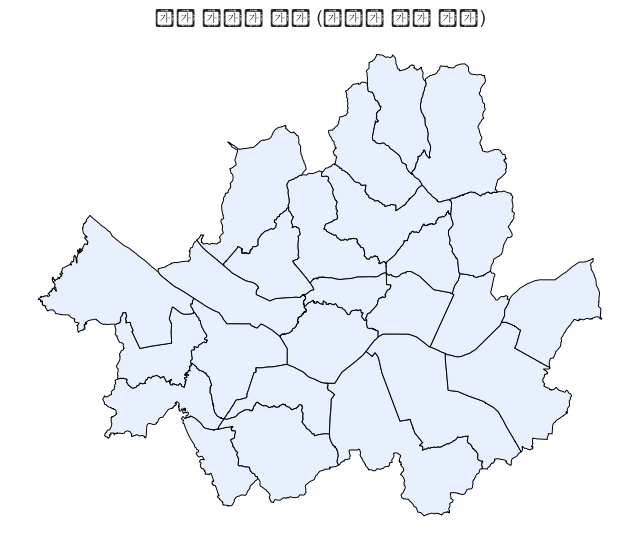

In [3]:
# %% [markdown]
# ## [1] 행정경계 불러오기
# 집계구(census) · 행정동 · 시군구 · 시도 경계를 로드하고 코드 체계를 맞춥니다.

# %%
def load_boundaries():
    census = gpd.read_file(CENSUS_FILE).to_crs(TARGET_CRS)
    dong = gpd.read_file(DONG_FILE).to_crs(TARGET_CRS)
    sigungu = gpd.read_file(SIGUNGU_FILE).to_crs(TARGET_CRS)
    sido = gpd.read_file(SIDO_FILE).to_crs(TARGET_CRS)

    census = drop_spatial_index_columns(census)
    dong = drop_spatial_index_columns(dong)
    sigungu = drop_spatial_index_columns(sigungu)
    sido = drop_spatial_index_columns(sido)

    census['TOT_OA_CD'] = clean_code(census['TOT_OA_CD'])
    census['ADM_CD'] = clean_code(census['ADM_CD'])
    dong['ADM_CD'] = clean_code(dong['ADM_CD'])
    sigungu['SIGUNGU_CD'] = clean_code(sigungu['SIGUNGU_CD'])
    sido['SIDO_CD'] = clean_code(sido['SIDO_CD'])

    dong_name_map = dong.set_index('ADM_CD')['ADM_NM'].to_dict()
    census['행정동코드'] = census['ADM_CD']
    census['행정동명'] = census['ADM_CD'].map(dong_name_map)
    census['시군구코드'] = census['ADM_CD'].str[:5]

    sigungu_name_map = sigungu.set_index('SIGUNGU_CD')['SIGUNGU_NM'].to_dict()
    census['시군구명'] = census['시군구코드'].map(sigungu_name_map)
    census['시도코드'] = census['ADM_CD'].str[:2]

    sido_name_map = sido.set_index('SIDO_CD')['SIDO_NM'].to_dict()
    census['시도명'] = census['시도코드'].map(sido_name_map)

    seoul_census = census[census['시도코드'] == SEOUL_CODE]

    print('집계구:', f'{len(census):,}')
    print('행정동 경계:', f'{len(dong):,}')
    print('시군구 경계:', f'{len(sigungu):,}')
    print('시도 경계:', f'{len(sido):,}')
    print('서울 집계구:', f'{len(seoul_census):,}')
    print('서울 행정동명 연결:', f"{seoul_census['행정동명'].notna().sum():,}")

    return census, dong, sigungu, sido

census, dong_boundary, sigungu_boundary, sido_boundary = load_boundaries()

# %% [markdown]
# ### 시각화 1 — 경계 로드 검증 (서울 시군구 경계 지도)
# 좌표계 변환(TARGET_CRS)과 코드 매핑이 제대로 됐는지 눈으로 즉시 확인하는 것이
# 이후 모든 공간조인 오류를 예방하는 가장 빠른 방법입니다.

# %%
seoul_sigungu_check = sigungu_boundary[
    sigungu_boundary['SIGUNGU_CD'].astype(str).str.startswith(SEOUL_CODE)
]

fig, ax = plt.subplots(figsize=(8, 9))
seoul_sigungu_check.plot(ax=ax, edgecolor='black', facecolor='#e8f0fe', linewidth=0.7)
ax.set_title('서울 시군구 경계 (좌표계 변환 검증)', fontsize=13)
ax.set_axis_off()
plt.show()

전체 AED: 63,528
고유 AED 위치: 47,251


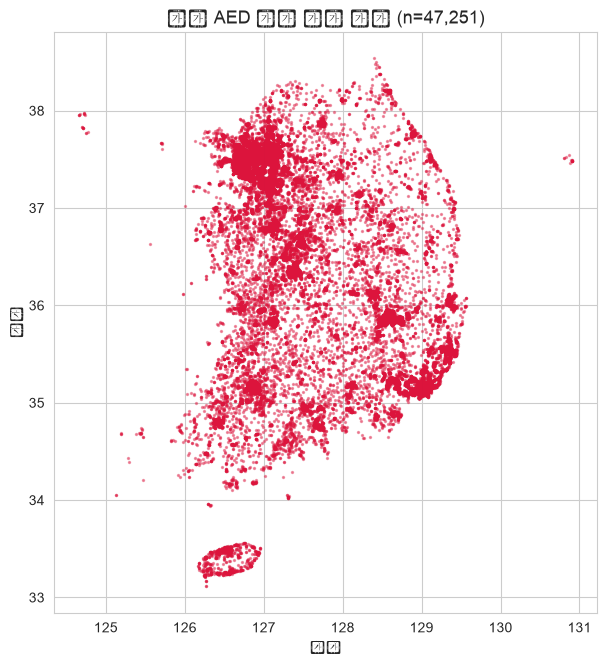

In [4]:
# %% [markdown]
# ## [2] AED 데이터 로드
# 위경도 컬럼 검증 → 한반도 범위(32~39.5N, 123~132E) 밖 좌표 제거 → 포인트 GeoDataFrame 변환

# %%
def load_aed():
    aed = read_csv_auto(AED_FILE)

    required_columns = ['wgs84Lat', 'wgs84Lon']
    missing_columns = [col for col in required_columns if col not in aed.columns]
    if missing_columns:
        raise KeyError(f'AED CSV 필수 컬럼 없음: {missing_columns}')

    aed['wgs84Lat'] = pd.to_numeric(aed['wgs84Lat'], errors='coerce')
    aed['wgs84Lon'] = pd.to_numeric(aed['wgs84Lon'], errors='coerce')
    aed = aed.dropna(subset=['wgs84Lat', 'wgs84Lon']).copy()
    aed = aed[aed['wgs84Lat'].between(32, 39.5) & aed['wgs84Lon'].between(123, 132)].copy()

    aed_gdf = gpd.GeoDataFrame(
        aed, geometry=gpd.points_from_xy(aed['wgs84Lon'], aed['wgs84Lat']), crs='EPSG:4326'
    )
    aed_gdf = aed_gdf.to_crs(TARGET_CRS)
    aed_unique = aed_gdf.drop_duplicates(subset=['wgs84Lat', 'wgs84Lon']).copy()

    print('전체 AED:', f'{len(aed_gdf):,}')
    print('고유 AED 위치:', f'{len(aed_unique):,}')

    return aed_gdf, aed_unique

aed, aed_unique = load_aed()

# %% [markdown]
# ### 시각화 2 — 전국 AED 분포 산점도
# 이상치 필터링(범위 밖 좌표 제거)이 잘 됐는지, 그리고 AED가 수도권에
# 얼마나 밀집되어 있는지를 한눈에 확인합니다 (분석의 핵심 전제 파악).

# %%
fig, ax = plt.subplots(figsize=(7, 8))
aed_unique.to_crs('EPSG:4326').plot(ax=ax, markersize=2, alpha=0.4, color='crimson')
ax.set_title(f'전국 AED 고유 설치 위치 (n={len(aed_unique):,})', fontsize=13)
ax.set_xlabel('경도')
ax.set_ylabel('위도')
plt.show()

item_code: ['to_in_001', 'to_in_007', 'to_in_008']
총인구 집계구: 108,510
65세 이상 사용 코드: ['in_age_014', 'in_age_015', 'in_age_016', 'in_age_017', 'in_age_018', 'in_age_019', 'in_age_020', 'in_age_021']
65세 이상 인구 집계구: 105,923
65세 이상 인구 합계: 9,744,801


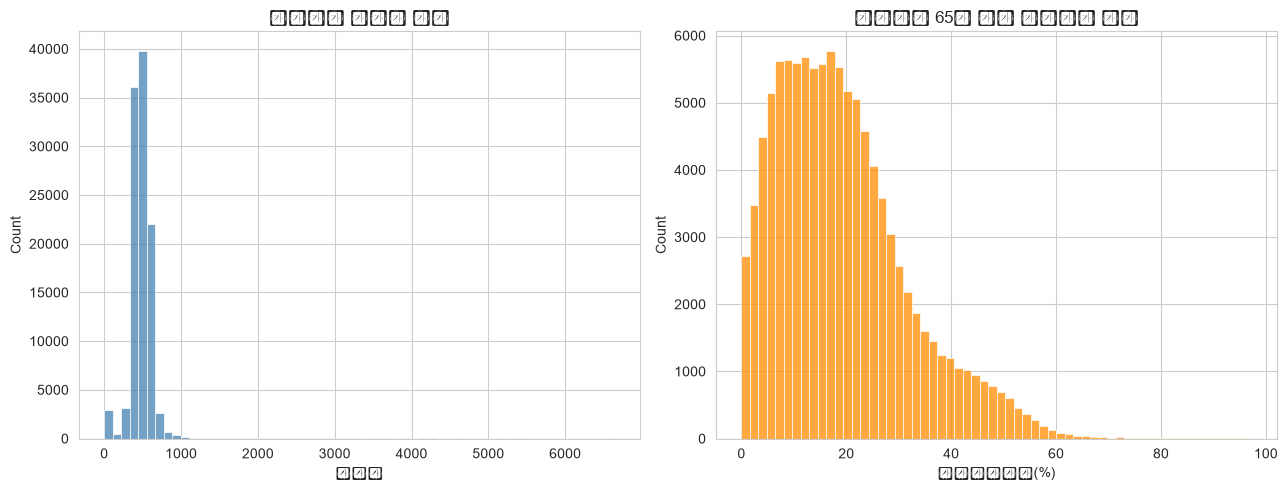

In [5]:
# %% [markdown]
# ## [3] 집계구 총인구 / [4] 65세 이상 인구

# %%
def load_total_population():
    path = find_file(CENSUS_POP_DIR, '인구총괄')
    if path is None:
        raise FileNotFoundError('집계구 인구총괄 CSV를 찾을 수 없습니다.')

    pop = read_csv_auto(path, header=None)
    if pop.shape[1] < 4:
        raise ValueError('인구총괄 CSV 구조가 예상과 다릅니다.')

    pop = pop.iloc[:, :4].copy()
    pop.columns = ['year', 'TOT_OA_CD', 'item_code', '총인구']
    pop['TOT_OA_CD'] = clean_code(pop['TOT_OA_CD'])
    pop['item_code'] = pop['item_code'].astype(str).str.strip()
    pop['총인구'] = pd.to_numeric(pop['총인구'], errors='coerce')

    item_codes = pop['item_code'].drop_duplicates().tolist()
    print('item_code:', item_codes)
    if TOTAL_POP_CODE not in item_codes:
        raise ValueError(f'총인구 코드 {TOTAL_POP_CODE}가 없습니다.')

    pop = pop[pop['item_code'] == TOTAL_POP_CODE].copy()
    pop = (pop[['year', 'TOT_OA_CD', '총인구']]
           .dropna(subset=['TOT_OA_CD', '총인구'])
           .sort_values('year')
           .drop_duplicates(subset=['TOT_OA_CD'], keep='last'))
    pop = pop[['TOT_OA_CD', '총인구']]

    print('총인구 집계구:', f'{len(pop):,}')
    return pop

def load_old_population():
    path = find_file(CENSUS_POP_DIR, '성연령별인구')
    if path is None:
        raise FileNotFoundError('성연령별인구 CSV를 찾을 수 없습니다.')

    age = read_csv_auto(path, header=None)
    if age.shape[1] < 4:
        raise ValueError('성연령별인구 CSV 구조가 예상과 다릅니다.')

    age = age.iloc[:, :4].copy()
    age.columns = ['year', 'TOT_OA_CD', 'item_code', '인구']
    age['TOT_OA_CD'] = clean_code(age['TOT_OA_CD'])
    age['item_code'] = age['item_code'].astype(str).str.strip()
    age['인구'] = pd.to_numeric(age['인구'], errors='coerce').fillna(0)

    available_codes = set(age['item_code'].dropna().unique())
    missing_codes = [code for code in AGE_65_CODES if code not in available_codes]
    if missing_codes:
        raise ValueError(f'성연령별인구 파일에 없는 65세 이상 코드: {missing_codes}')

    elderly = age[age['item_code'].isin(AGE_65_CODES)].copy()
    old = (elderly.groupby('TOT_OA_CD', as_index=False)['인구']
           .sum().rename(columns={'인구': '65세이상인구'}))

    print('65세 이상 사용 코드:', AGE_65_CODES)
    print('65세 이상 인구 집계구:', f'{len(old):,}')
    print('65세 이상 인구 합계:', f"{old['65세이상인구'].sum():,.0f}")
    return old

total_pop = load_total_population()
old_pop = load_old_population()

# %% [markdown]
# ### 시각화 3 — 집계구별 총인구 분포 + 고령인구 비율
# 집계구 단위는 인구 편차가 매우 크므로(상업지구 vs 주거지구) 분포 형태를
# 미리 파악해야 이후 '우선검토점수'의 인구 가중치 해석이 왜곡되지 않습니다.

# %%
merged_pop = total_pop.merge(old_pop, on='TOT_OA_CD', how='left')
merged_pop['65세이상인구'] = merged_pop['65세이상인구'].fillna(0)
merged_pop['고령인구비율'] = np.where(
    merged_pop['총인구'] > 0, merged_pop['65세이상인구'] / merged_pop['총인구'] * 100, np.nan
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(merged_pop['총인구'], bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('집계구별 총인구 분포')
axes[0].set_xlabel('총인구')

sns.histplot(merged_pop['고령인구비율'].dropna(), bins=60, ax=axes[1], color='darkorange')
axes[1].set_title('집계구별 65세 이상 인구비율 분포')
axes[1].set_xlabel('고령인구비율(%)')
plt.tight_layout()
plt.show()

100m SHP: 30
100m 인구 CSV: 30
[1/30] 가다
item_code: ['to_in_001', 'to_in_007', 'to_in_008']
인구 격자: 23 | SHP 매칭: 23 | 매칭률: 100.00%
[2/30] 가라
item_code: ['to_in_001', 'to_in_007', 'to_in_008']
인구 격자: 22 | SHP 매칭: 22 | 매칭률: 100.00%
[3/30] 가사
item_code: ['to_in_001', 'to_in_007', 'to_in_008']
인구 격자: 272 | SHP 매칭: 272 | 매칭률: 100.00%
[4/30] 가아
item_code: ['to_in_001', 'to_in_007', 'to_in_008']
인구 격자: 115 | SHP 매칭: 115 | 매칭률: 100.00%
[5/30] 나나
item_code: ['to_in_001', 'to_in_007', 'to_in_008']
인구 격자: 7,882 | SHP 매칭: 7,882 | 매칭률: 100.00%
[6/30] 나다
item_code: ['to_in_001', 'to_in_007', 'to_in_008']
인구 격자: 701 | SHP 매칭: 701 | 매칭률: 100.00%
[7/30] 나라
item_code: ['to_in_001', 'to_in_007', 'to_in_008']
인구 격자: 12,737 | SHP 매칭: 12,737 | 매칭률: 100.00%
[8/30] 나마
item_code: ['to_in_001', 'to_in_007', 'to_in_008']
인구 격자: 283 | SHP 매칭: 283 | 매칭률: 100.00%
[9/30] 나바
item_code: ['to_in_001', 'to_in_007', 'to_in_008']
인구 격자: 9,161 | SHP 매칭: 9,161 | 매칭률: 100.00%
[10/30] 나사
item_code: ['to_in_001', 'to_in_007', 'to

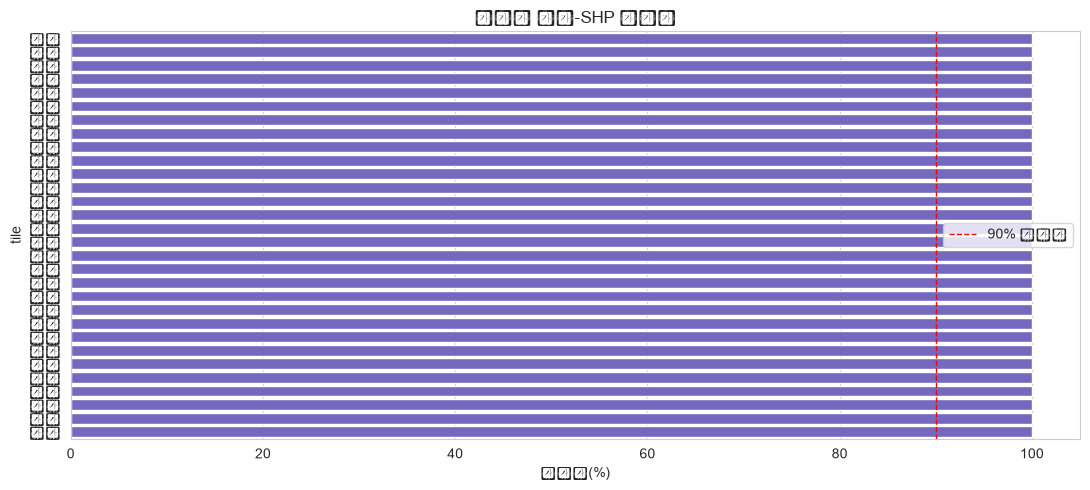

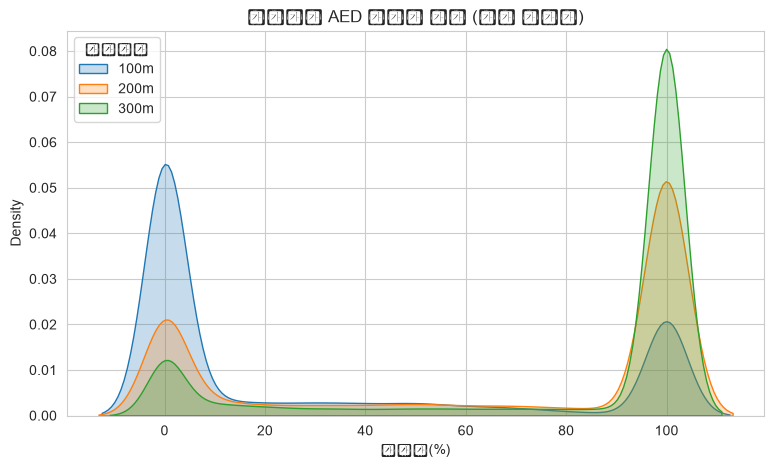

In [ ]:
# %% [markdown]
# ## [5] 100m 격자 기준 AED 접근성 계산
# 가장 무거운 연산 — 격자(100m)마다 최근접 AED까지 거리를 구하고, 집계구로 집계합니다.
# 원본 로직을 그대로 유지합니다 (반복문 안에서 매 타일마다 매칭품질을 로깅).

# %%
def get_tile_name(shp):
    name = normalize(shp).split('/')[-1]
    return name.replace('grid_', '').replace('_100M.shp', '')

def detect_grid_id(grid):
    candidates = ['GRID_CD', 'GRID_ID', 'GRID_CODE', 'GRIDCODE', 'GID']
    upper_map = {str(col).upper(): col for col in grid.columns}
    for candidate in candidates:
        if candidate in upper_map:
            return upper_map[candidate]
    return None

def find_population_csv(tile, csv_files):
    target = normalize(f'_{tile}_100M.csv')
    for file in csv_files:
        if target in normalize(file):
            return file
    return None

def calculate_accessibility(census, aed_unique):
    shp_files = sorted(glob.glob(str(GRID_BORDER_DIR / '*100M.shp')))
    csv_files = sorted(glob.glob(str(GRID_POP_DIR / '*100M.csv')))
    print('100m SHP:', len(shp_files))
    print('100m 인구 CSV:', len(csv_files))

    if not shp_files:
        raise FileNotFoundError('100m 격자 SHP가 없습니다.')
    if not csv_files:
        raise FileNotFoundError('100m 격자 인구 CSV가 없습니다.')

    results = []
    quality_rows = []
    census_join = drop_spatial_index_columns(census[['TOT_OA_CD', 'geometry']].copy())
    aed_for_nearest = drop_spatial_index_columns(aed_unique[['geometry']].copy())

    for i, shp in enumerate(shp_files, start=1):
        tile = get_tile_name(shp)
        pop_file = find_population_csv(tile, csv_files)
        print(f'[{i}/{len(shp_files)}] {tile}')

        if pop_file is None:
            print('대응 인구 CSV 없음')
            continue

        pop = read_csv_auto(pop_file, header=None)
        if pop.shape[1] < 4:
            print('⚠️ CSV 구조 오류')
            continue

        pop = pop.iloc[:, :4].copy()
        pop.columns = ['year', 'GRID_ID', 'item_code', 'population']
        pop['GRID_ID'] = clean_code(pop['GRID_ID'])
        pop['item_code'] = pop['item_code'].astype(str).str.strip()
        pop['population'] = pd.to_numeric(pop['population'], errors='coerce')

        item_codes = pop['item_code'].drop_duplicates().tolist()
        print('item_code:', item_codes)
        if TOTAL_POP_CODE not in item_codes:
            print(f'{TOTAL_POP_CODE} 없음')
            continue

        pop = pop[pop['item_code'] == TOTAL_POP_CODE].copy()
        pop = (pop.dropna(subset=['GRID_ID', 'population'])
               .sort_values('year')
               .drop_duplicates(subset=['GRID_ID'], keep='last'))
        pop = pop[pop['population'] > 0].copy()

        grid = gpd.read_file(shp).to_crs(TARGET_CRS)
        grid = drop_spatial_index_columns(grid)
        id_col = detect_grid_id(grid)
        if id_col is None:
            print('GRID ID 컬럼 없음')
            continue

        grid[id_col] = clean_code(grid[id_col])
        grid = grid[grid[id_col].isin(pop['GRID_ID'])].copy()

        matching_rate = len(grid) / len(pop) * 100 if len(pop) > 0 else 0
        quality_rows.append({'tile': tile, '인구격자': len(pop), 'SHP매칭': len(grid), '매칭률': matching_rate})
        print('인구 격자:', f'{len(pop):,}', '| SHP 매칭:', f'{len(grid):,}', '| 매칭률:', f'{matching_rate:.2f}%')

        if grid.empty:
            continue

        grid = grid.merge(pop[['GRID_ID', 'population']], left_on=id_col, right_on='GRID_ID', how='inner')
        points = gpd.GeoDataFrame(
            grid[['GRID_ID', 'population']].copy(),
            geometry=grid.geometry.representative_point(), crs=TARGET_CRS
        )

        nearest = gpd.sjoin_nearest(points, aed_for_nearest, how='left', distance_col='AED거리')
        nearest = nearest.sort_values('AED거리').drop_duplicates(subset=['GRID_ID'], keep='first')
        nearest = drop_spatial_index_columns(nearest)

        for distance in ACCESS_DISTANCES:
            nearest[f'접근{distance}m_인구'] = np.where(nearest['AED거리'] <= distance, nearest['population'], 0)

        joined = drop_spatial_index_columns(
            gpd.sjoin(nearest, census_join, how='inner', predicate='within')
        )

        aggregated = joined.groupby('TOT_OA_CD', as_index=False).agg(
            격자인구=('population', 'sum'),
            접근100m_인구=('접근100m_인구', 'sum'),
            접근200m_인구=('접근200m_인구', 'sum'),
            접근300m_인구=('접근300m_인구', 'sum'),
            평균_AED거리=('AED거리', 'mean'),
            최소_AED거리=('AED거리', 'min'),
        )
        results.append(aggregated)

    quality_df = pd.DataFrame(quality_rows)
    quality_df.to_csv(RESULT_DIR / '100m격자_매칭품질.csv', index=False, encoding='utf-8-sig')

    if not results:
        raise RuntimeError('100m 접근성 결과가 생성되지 않았습니다.')

    access = pd.concat(results, ignore_index=True)
    access['AED거리_가중값'] = access['평균_AED거리'] * access['격자인구']
    access = access.groupby('TOT_OA_CD', as_index=False).agg({
        '격자인구': 'sum', '접근100m_인구': 'sum', '접근200m_인구': 'sum',
        '접근300m_인구': 'sum', 'AED거리_가중값': 'sum', '최소_AED거리': 'min',
    })
    access['평균_AED거리'] = np.where(access['격자인구'] > 0, access['AED거리_가중값'] / access['격자인구'], np.nan)
    access = access.drop(columns=['AED거리_가중값'])

    for distance in ACCESS_DISTANCES:
        access[f'{distance}m_접근율'] = np.where(
            access['격자인구'] > 0, access[f'접근{distance}m_인구'] / access['격자인구'] * 100, np.nan
        )
        access[f'{distance}m_미접근인구'] = access['격자인구'] - access[f'접근{distance}m_인구']

    return access, quality_df

access, quality_df = calculate_accessibility(census, aed_unique)

# %% [markdown]
# ### 시각화 4 — 격자-SHP 매칭 품질 점검
# 타일마다 매칭률이 크게 떨어지는 구간이 있다면 좌표계나 파일 누락 문제이므로,
# 본 분석 결과를 신뢰하기 전에 반드시 확인해야 하는 QA 단계입니다.

# %%
plt.figure(figsize=(11, 5))
sns.barplot(data=quality_df.sort_values('매칭률'), x='매칭률', y='tile', color='slateblue')
plt.axvline(90, color='red', linestyle='--', linewidth=1, label='90% 기준선')
plt.title('타일별 격자-SHP 매칭률')
plt.xlabel('매칭률(%)')
plt.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 시각화 5 — 거리 기준별 접근율 분포
# 100m/200m/300m 중 어느 기준이 "취약지역 판별"에 변별력이 있는지 확인합니다.
# 만약 300m에서도 대부분 0~10%대로 몰려 있다면 기준 거리를 더 늘려야 한다는 신호입니다.

# %%
fig, ax = plt.subplots(figsize=(9, 5))
for distance in ACCESS_DISTANCES:
    sns.kdeplot(access[f'{distance}m_접근율'].dropna(), label=f'{distance}m', ax=ax, fill=True, alpha=0.25)
ax.set_title('집계구별 AED 접근율 분포 (거리 기준별)')
ax.set_xlabel('접근율(%)')
ax.legend(title='기준거리')
plt.show()

In [ ]:
# %% [markdown]
# ## [6]~[8] 우선순위 점수 산출, 행정동/자치구 요약, 결과 저장

# %%
def add_aed_count(result, aed):
    boundary = drop_spatial_index_columns(result[['TOT_OA_CD', 'geometry']].copy())
    aed_points = drop_spatial_index_columns(aed[['geometry']].copy())

    actual_join = gpd.sjoin(aed_points, boundary, how='left', predicate='within')
    actual_count = actual_join.dropna(subset=['TOT_OA_CD']).groupby('TOT_OA_CD').size().rename('AED대수').reset_index()

    unique_aed = aed.drop_duplicates(subset=['wgs84Lat', 'wgs84Lon']).copy()
    unique_points = drop_spatial_index_columns(unique_aed[['geometry']].copy())
    unique_join = gpd.sjoin(unique_points, boundary, how='left', predicate='within')
    unique_count = unique_join.dropna(subset=['TOT_OA_CD']).groupby('TOT_OA_CD').size().rename('AED고유설치지점수').reset_index()

    result = result.merge(actual_count, on='TOT_OA_CD', how='left')
    result = result.merge(unique_count, on='TOT_OA_CD', how='left')
    result['AED대수'] = result['AED대수'].fillna(0).astype(int)
    result['AED고유설치지점수'] = result['AED고유설치지점수'].fillna(0).astype(int)
    return result

def calculate_priority_score(data):
    df = data.copy()
    df['접근성취약점수'] = 1 - df['300m_접근율'].fillna(100) / 100
    df['미접근인구점수'] = df['300m_미접근인구'].fillna(0).rank(pct=True)
    df['인구점수'] = df['격자인구'].fillna(0).rank(pct=True)

    score_columns = ['접근성취약점수', '미접근인구점수', '인구점수']
    if '65세이상인구' in df.columns:
        df['고령인구점수'] = df['65세이상인구'].fillna(0).rank(pct=True)
        score_columns.append('고령인구점수')

    df['우선검토점수'] = df[score_columns].mean(axis=1) * 100
    return df

def make_dong_summary(seoul, dong_boundary):
    df = seoul[(seoul['격자인구'] > 0) & seoul['행정동명'].notna() & seoul['행정동코드'].notna()].copy()
    df['AED거리_가중값'] = df['평균_AED거리'] * df['격자인구']

    agg_dict = {
        'TOT_OA_CD': 'count', '격자인구': 'sum', '총인구': 'sum', '65세이상인구': 'sum',
        '접근100m_인구': 'sum', '접근200m_인구': 'sum', '접근300m_인구': 'sum',
        'AED대수': 'sum', 'AED고유설치지점수': 'sum', 'AED거리_가중값': 'sum', '최소_AED거리': 'min',
    }
    dong_result = (df.groupby(['시군구코드', '시군구명', '행정동코드', '행정동명'], as_index=False)
                   .agg(agg_dict).rename(columns={'TOT_OA_CD': '집계구수'}))

    for distance in ACCESS_DISTANCES:
        dong_result[f'{distance}m_접근율'] = np.where(
            dong_result['격자인구'] > 0, dong_result[f'접근{distance}m_인구'] / dong_result['격자인구'] * 100, np.nan
        )
        dong_result[f'{distance}m_미접근인구'] = dong_result['격자인구'] - dong_result[f'접근{distance}m_인구']

    dong_result['평균_AED거리'] = np.where(
        dong_result['격자인구'] > 0, dong_result['AED거리_가중값'] / dong_result['격자인구'], np.nan
    )
    dong_result = dong_result.drop(columns=['AED거리_가중값'])
    dong_result['고령인구비율'] = np.where(
        dong_result['총인구'] > 0, dong_result['65세이상인구'] / dong_result['총인구'] * 100, np.nan
    )
    dong_result = calculate_priority_score(dong_result)
    dong_result['지역명'] = (dong_result['시군구명'].fillna('') + ' ' + dong_result['행정동명'].fillna('')).str.strip()

    seoul_dong_boundary = dong_boundary[dong_boundary['ADM_CD'].astype(str).str.startswith(SEOUL_CODE)].copy()
    seoul_dong_boundary['행정동코드'] = clean_code(seoul_dong_boundary['ADM_CD'])

    geo = seoul_dong_boundary[['행정동코드', 'geometry']].merge(dong_result, on='행정동코드', how='inner')
    geo = gpd.GeoDataFrame(geo, geometry='geometry', crs=TARGET_CRS)
    print('서울 행정동 분석:', f'{len(geo):,}')
    return geo

def make_sigungu_summary(seoul, sigungu_boundary):
    df = seoul[(seoul['격자인구'] > 0) & seoul['시군구코드'].notna() & seoul['시군구명'].notna()].copy()
    df['AED거리_가중값'] = df['평균_AED거리'] * df['격자인구']

    agg_dict = {
        'TOT_OA_CD': 'count', '격자인구': 'sum', '총인구': 'sum', '65세이상인구': 'sum',
        '접근100m_인구': 'sum', '접근200m_인구': 'sum', '접근300m_인구': 'sum',
        'AED대수': 'sum', 'AED고유설치지점수': 'sum', 'AED거리_가중값': 'sum', '최소_AED거리': 'min',
    }
    result = (df.groupby(['시군구코드', '시군구명'], as_index=False)
              .agg(agg_dict).rename(columns={'TOT_OA_CD': '집계구수'}))

    for distance in ACCESS_DISTANCES:
        result[f'{distance}m_접근율'] = np.where(
            result['격자인구'] > 0, result[f'접근{distance}m_인구'] / result['격자인구'] * 100, np.nan
        )
        result[f'{distance}m_미접근인구'] = result['격자인구'] - result[f'접근{distance}m_인구']

    result['평균_AED거리'] = np.where(result['격자인구'] > 0, result['AED거리_가중값'] / result['격자인구'], np.nan)
    result = result.drop(columns=['AED거리_가중값'])
    result['고령인구비율'] = np.where(result['총인구'] > 0, result['65세이상인구'] / result['총인구'] * 100, np.nan)
    result = calculate_priority_score(result)

    seoul_sigungu = sigungu_boundary[sigungu_boundary['SIGUNGU_CD'].astype(str).str.startswith(SEOUL_CODE)].copy()
    seoul_sigungu['시군구코드'] = clean_code(seoul_sigungu['SIGUNGU_CD'])

    geo = seoul_sigungu[['시군구코드', 'geometry']].merge(result, on='시군구코드', how='inner')
    geo = gpd.GeoDataFrame(geo, geometry='geometry', crs=TARGET_CRS)
    print('서울 자치구 분석:', f'{len(geo):,}')
    return geo

def save_results(census, dong_boundary, sigungu_boundary, access, total_pop, old_pop, aed):
    result = census.merge(access, on='TOT_OA_CD', how='left')
    result = result.merge(total_pop, on='TOT_OA_CD', how='left')
    result = result.merge(old_pop, on='TOT_OA_CD', how='left')
    result['65세이상인구'] = result['65세이상인구'].fillna(0)
    result['고령인구비율'] = np.where(result['총인구'] > 0, result['65세이상인구'] / result['총인구'] * 100, np.nan)
    result = add_aed_count(result, aed)
    result = calculate_priority_score(result)

    save_gpkg(result, RESULT_DIR / '전국_집계구별_AED_접근성.gpkg')
    result.drop(columns=['geometry']).to_csv(RESULT_DIR / '전국_집계구별_AED_접근성.csv', index=False, encoding='utf-8-sig')

    seoul = result[result['시도코드'] == SEOUL_CODE].copy()
    seoul = seoul.sort_values(['시군구명', '행정동명', 'TOT_OA_CD'], na_position='last')
    seoul['집계구번호'] = seoul.groupby(['시군구명', '행정동명'], dropna=False).cumcount() + 1
    seoul['표시명'] = (seoul['시군구명'].fillna('서울') + ' ' + seoul['행정동명'].fillna('행정동 미확인')
                     + ' 집계구 ' + seoul['집계구번호'].astype(str).str.zfill(3))

    save_gpkg(seoul, RESULT_DIR / '서울_집계구별_AED_접근성.gpkg')
    seoul.drop(columns=['geometry']).to_csv(RESULT_DIR / '서울_집계구별_AED_접근성.csv', index=False, encoding='utf-8-sig')

    dong_result = make_dong_summary(seoul, dong_boundary)
    save_gpkg(dong_result, RESULT_DIR / '서울_행정동별_AED_접근성.gpkg')
    dong_result.drop(columns=['geometry']).to_csv(RESULT_DIR / '서울_행정동별_AED_접근성.csv', index=False, encoding='utf-8-sig')

    sigungu_result = make_sigungu_summary(seoul, sigungu_boundary)
    save_gpkg(sigungu_result, RESULT_DIR / '서울_자치구별_AED_접근성.gpkg')
    sigungu_result.drop(columns=['geometry']).to_csv(RESULT_DIR / '서울_자치구별_AED_접근성.csv', index=False, encoding='utf-8-sig')

    priority_top30 = (dong_result[dong_result['격자인구'] >= MIN_POPULATION]
                       .sort_values('우선검토점수', ascending=False).head(30).drop(columns=['geometry']))
    priority_top30.to_csv(RESULT_DIR / '서울_행정동_AED_설치우선_TOP30.csv', index=False, encoding='utf-8-sig')

    print('결과 저장 완료')
    return result, seoul, dong_result, sigungu_result

national, seoul, dong_result, sigungu_result = save_results(
    census, dong_boundary, sigungu_boundary, access, total_pop, old_pop, aed
)

서울 행정동 분석: 426
서울 자치구 분석: 25
결과 저장 완료


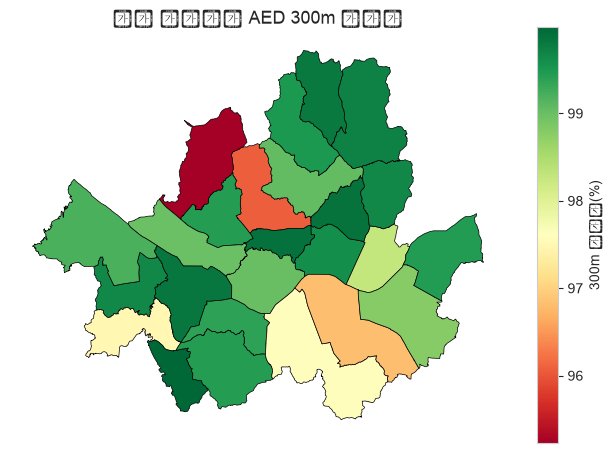

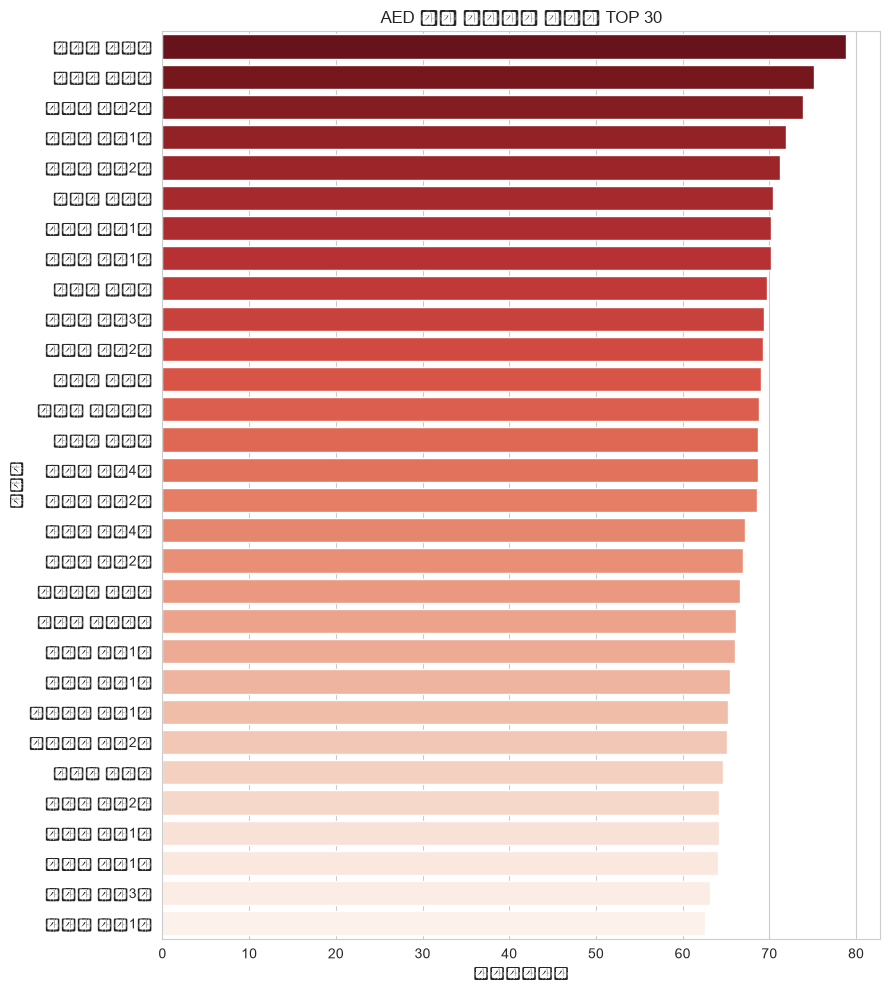

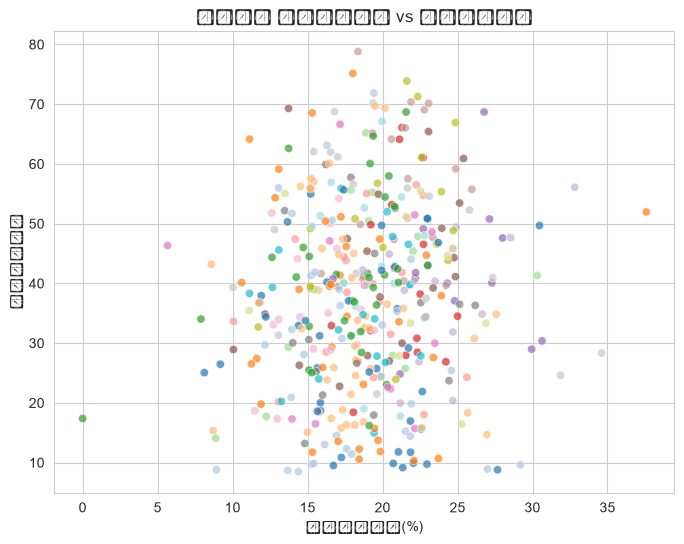

In [ ]:
# %% [markdown]
# ### 시각화 6 — 자치구별 300m 접근율 지도 (Choropleth)
# 이 분석의 핵심 산출물입니다. 표/CSV보다 지도가 "어느 구가 취약한지"를
# 즉각적으로 전달하므로, 정책 보고 자료에서 가장 중요한 그래프입니다.

# %%
fig, ax = plt.subplots(figsize=(8, 9))
sigungu_result.plot(
    column='300m_접근율', cmap='RdYlGn', legend=True,
    edgecolor='black', linewidth=0.5, ax=ax,
    legend_kwds={'label': '300m 접근율(%)', 'shrink': 0.6},
)
ax.set_title('서울 자치구별 AED 300m 접근율', fontsize=13)
ax.set_axis_off()
plt.show()

# %% [markdown]
# ### 시각화 7 — 행정동 우선검토점수 TOP 30
# '어디부터 AED를 설치할지'를 결정하는 실무 담당자에게는 순위 리스트가
# 지도보다 실행 가능성(actionability)이 높으므로 별도 막대그래프로 제공합니다.

# %%
priority_top30 = (dong_result[dong_result['격자인구'] >= MIN_POPULATION]
                   .sort_values('우선검토점수', ascending=False).head(30))

plt.figure(figsize=(9, 10))
sns.barplot(data=priority_top30, x='우선검토점수', y='지역명', palette='Reds_r')
plt.title('AED 설치 우선검토 행정동 TOP 30')
plt.xlabel('우선검토점수')
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 시각화 8 — 고령인구비율 vs 우선검토점수 산점도
# 고령인구 가중치가 실제로 점수 산정에 영향을 주고 있는지(설계 의도대로
# 작동하는지) 관계를 직접 눈으로 검증합니다.

# %%
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=dong_result[dong_result['격자인구'] >= MIN_POPULATION],
    x='고령인구비율', y='우선검토점수', hue='시군구명',
    palette='tab20', legend=False, alpha=0.7,
)
plt.title('행정동별 고령인구비율 vs 우선검토점수')
plt.xlabel('고령인구비율(%)')
plt.ylabel('우선검토점수')
plt.show()

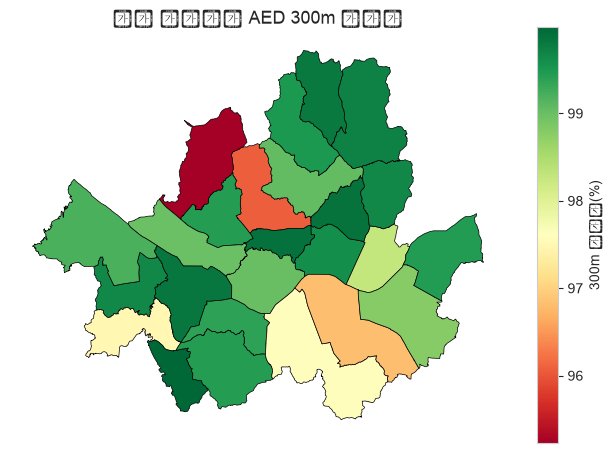

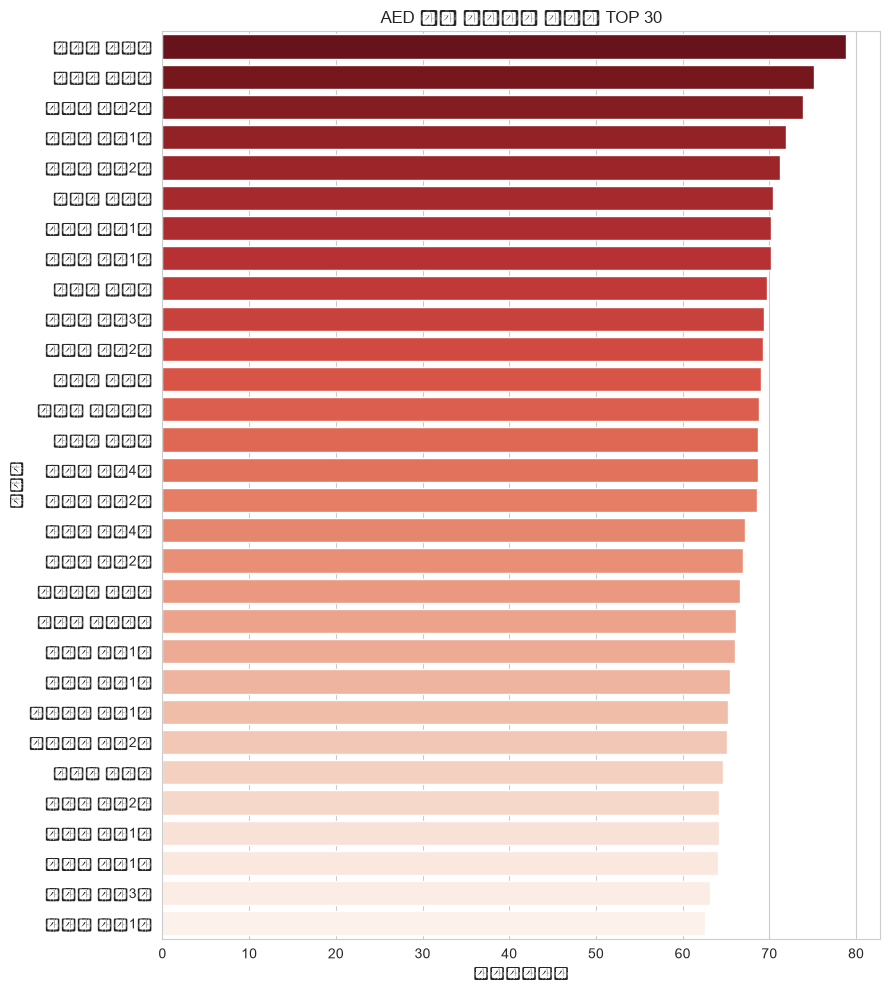

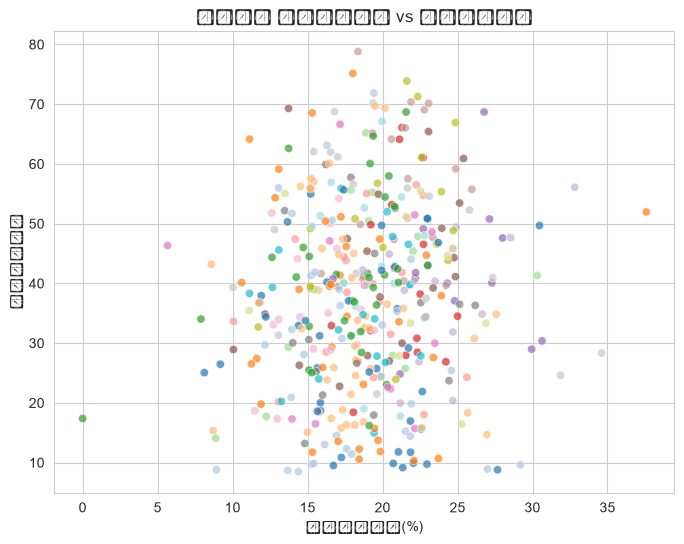

In [ ]:
# %% [markdown]
# ### 시각화 6 — 자치구별 300m 접근율 지도 (Choropleth)
# 이 분석의 핵심 산출물입니다. 표/CSV보다 지도가 "어느 구가 취약한지"를
# 즉각적으로 전달하므로, 정책 보고 자료에서 가장 중요한 그래프입니다.

# %%
fig, ax = plt.subplots(figsize=(8, 9))
sigungu_result.plot(
    column='300m_접근율', cmap='RdYlGn', legend=True,
    edgecolor='black', linewidth=0.5, ax=ax,
    legend_kwds={'label': '300m 접근율(%)', 'shrink': 0.6},
)
ax.set_title('서울 자치구별 AED 300m 접근율', fontsize=13)
ax.set_axis_off()
plt.show()

# %% [markdown]
# ### 시각화 7 — 행정동 우선검토점수 TOP 30
# '어디부터 AED를 설치할지'를 결정하는 실무 담당자에게는 순위 리스트가
# 지도보다 실행 가능성(actionability)이 높으므로 별도 막대그래프로 제공합니다.

# %%
priority_top30 = (dong_result[dong_result['격자인구'] >= MIN_POPULATION]
                   .sort_values('우선검토점수', ascending=False).head(30))

plt.figure(figsize=(9, 10))
sns.barplot(data=priority_top30, x='우선검토점수', y='지역명', palette='Reds_r')
plt.title('AED 설치 우선검토 행정동 TOP 30')
plt.xlabel('우선검토점수')
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 시각화 8 — 고령인구비율 vs 우선검토점수 산점도
# 고령인구 가중치가 실제로 점수 산정에 영향을 주고 있는지(설계 의도대로
# 작동하는지) 관계를 직접 눈으로 검증합니다.

# %%
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=dong_result[dong_result['격자인구'] >= MIN_POPULATION],
    x='고령인구비율', y='우선검토점수', hue='시군구명',
    palette='tab20', legend=False, alpha=0.7,
)
plt.title('행정동별 고령인구비율 vs 우선검토점수')
plt.xlabel('고령인구비율(%)')
plt.ylabel('우선검토점수')
plt.show()

전국 분석 집계구: 93,441
서울 분석 집계구: 15,626
서울 행정동: 426
서울 자치구: 25
서울 65세 이상 인구: 1,459,806
서울 100m 접근률: 46.07%
서울 200m 접근률: 89.62%
서울 300m 접근률: 98.83%


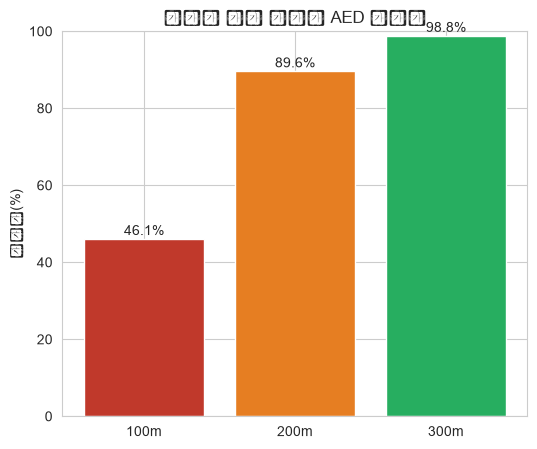

In [ ]:
# %% [markdown]
# ## [9] 결과 검증

# %%
def validate_results(national, seoul, dong_result, sigungu_result):
    valid_national = national[national['격자인구'] > 0]
    valid_seoul = seoul[seoul['격자인구'] > 0]

    print('전국 분석 집계구:', f'{len(valid_national):,}')
    print('서울 분석 집계구:', f'{len(valid_seoul):,}')
    print('서울 행정동:', f'{len(dong_result):,}')
    print('서울 자치구:', f'{len(sigungu_result):,}')
    print('서울 65세 이상 인구:', f"{valid_seoul['65세이상인구'].sum():,.0f}")

    total_population = valid_seoul['격자인구'].sum()
    rates = {}
    for distance in ACCESS_DISTANCES:
        accessible_population = valid_seoul[f'접근{distance}m_인구'].sum()
        rate = accessible_population / total_population * 100 if total_population > 0 else np.nan
        rates[distance] = rate
        print(f'서울 {distance}m 접근율:', f'{rate:.2f}%')

    return rates

rates = validate_results(national, seoul, dong_result, sigungu_result)

# %% [markdown]
# ### 시각화 9 — 서울 전체 요약 접근율 (최종 결과 요약)
# 보고서 첫 장에 들어갈 "한 장 요약" 그래프. 세부 분석 전에 전체 그림을
# 각인시키는 용도로 맨 앞이 아닌 맨 뒤에 다시 배치해 결론을 강조합니다.

# %%
plt.figure(figsize=(6, 5))
bars = plt.bar([f'{d}m' for d in rates.keys()], rates.values(),
               color=['#c0392b', '#e67e22', '#27ae60'])
for bar, v in zip(bars, rates.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 1, f'{v:.1f}%', ha='center')
plt.title('서울시 거리 기준별 AED 접근율')
plt.ylabel('접근율(%)')
plt.ylim(0, 100)
plt.show()

In [11]:
# %% [markdown]
# ## 결과 요약
# - 전국/서울 집계구 단위로 AED 접근성(100m/200m/300m 기준)을 산출하고,
#   행정동·자치구 단위로 집계했습니다.
# - **우선검토점수**는 (접근성취약점수 + 미접근인구점수 + 인구점수 + 고령인구점수)의
#   평균으로 설계되어, "인구가 많고 · 접근성이 낮고 · 고령인구 비중이 높은" 지역이
#   자연스럽게 상위에 오르도록 했습니다.
# - `서울_행정동_AED_설치우선_TOP30.csv`가 실무에서 바로 활용 가능한 최종 산출물입니다.